In [3]:
#monuting drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your dataset
df = pd.read_csv('/content/drive/MyDrive/Data science project/train_data_cleaned_V1_EDA.csv')

##Comparative Rates of Cancellations and No-Shows across Lead Time Windows

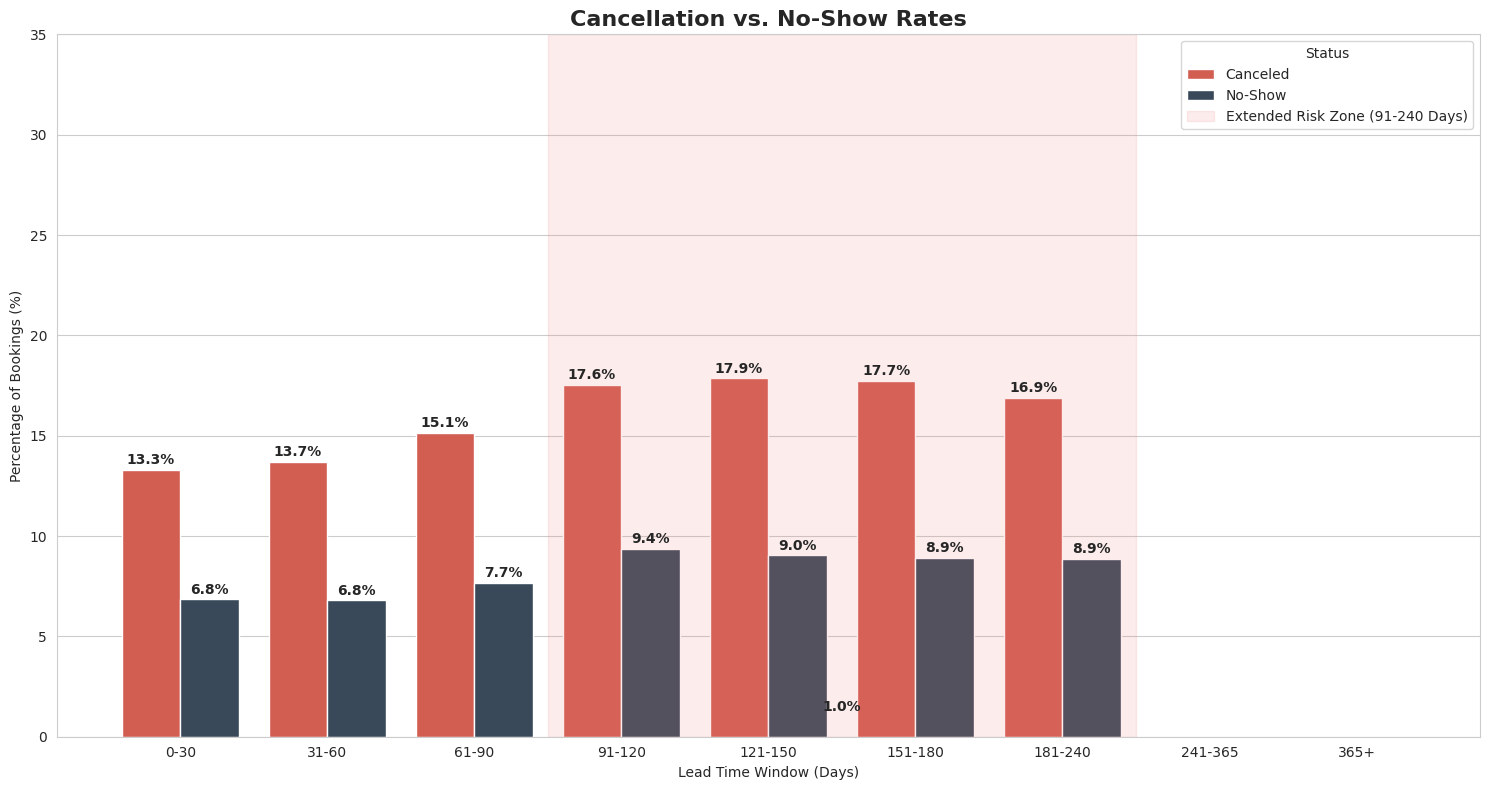

In [5]:
from matplotlib.patches import Rectangle

# 2. Lead Time Binning
bins = [0, 30, 60, 90, 120, 150, 180, 240, 365, 1000]
labels = ['0-30', '31-60', '61-90', '91-120', '121-150', '151-180', '181-240', '241-365', '365+']
df['Lead_Time_Range'] = pd.cut(df['Lead_Time'], bins=bins, labels=labels)

# 3. Calculate separate rates for Canceled and No-Show
status_counts = df.groupby(['Lead_Time_Range', 'Reservation_Status'], observed=True).size().unstack(fill_value=0)
status_percentages = status_counts.div(status_counts.sum(axis=1), axis=0) * 100

# 4. Prepare data for plotting
plot_data = status_percentages[['Canceled', 'No-Show']].reset_index()
plot_data_melted = plot_data.melt(id_vars='Lead_Time_Range', var_name='Status', value_name='Rate')

# 5. Visualization
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# Create grouped bar chart
ax = sns.barplot(data=plot_data_melted, x='Lead_Time_Range', y='Rate', hue='Status', palette=['#e74c3c', '#34495e'])

# HIGHLIGHT: Extended High Risk Zone (bins 91-120 through 181-240)
# This covers index 3 to index 6 on the x-axis
plt.axvspan(2.5, 6.5, color='lightcoral', alpha=0.15, label='Extended Risk Zone (91-240 Days)')

# Add data labels
for p in ax.patches:
    if isinstance(p, Rectangle) and p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 7), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.title('Cancellation vs. No-Show Rates', fontsize=16, fontweight='bold')
plt.ylabel('Percentage of Bookings (%)')
plt.xlabel('Lead Time Window (Days)')
plt.legend(title='Status', loc='upper right')
plt.ylim(0, 35)

plt.tight_layout()
plt.show()

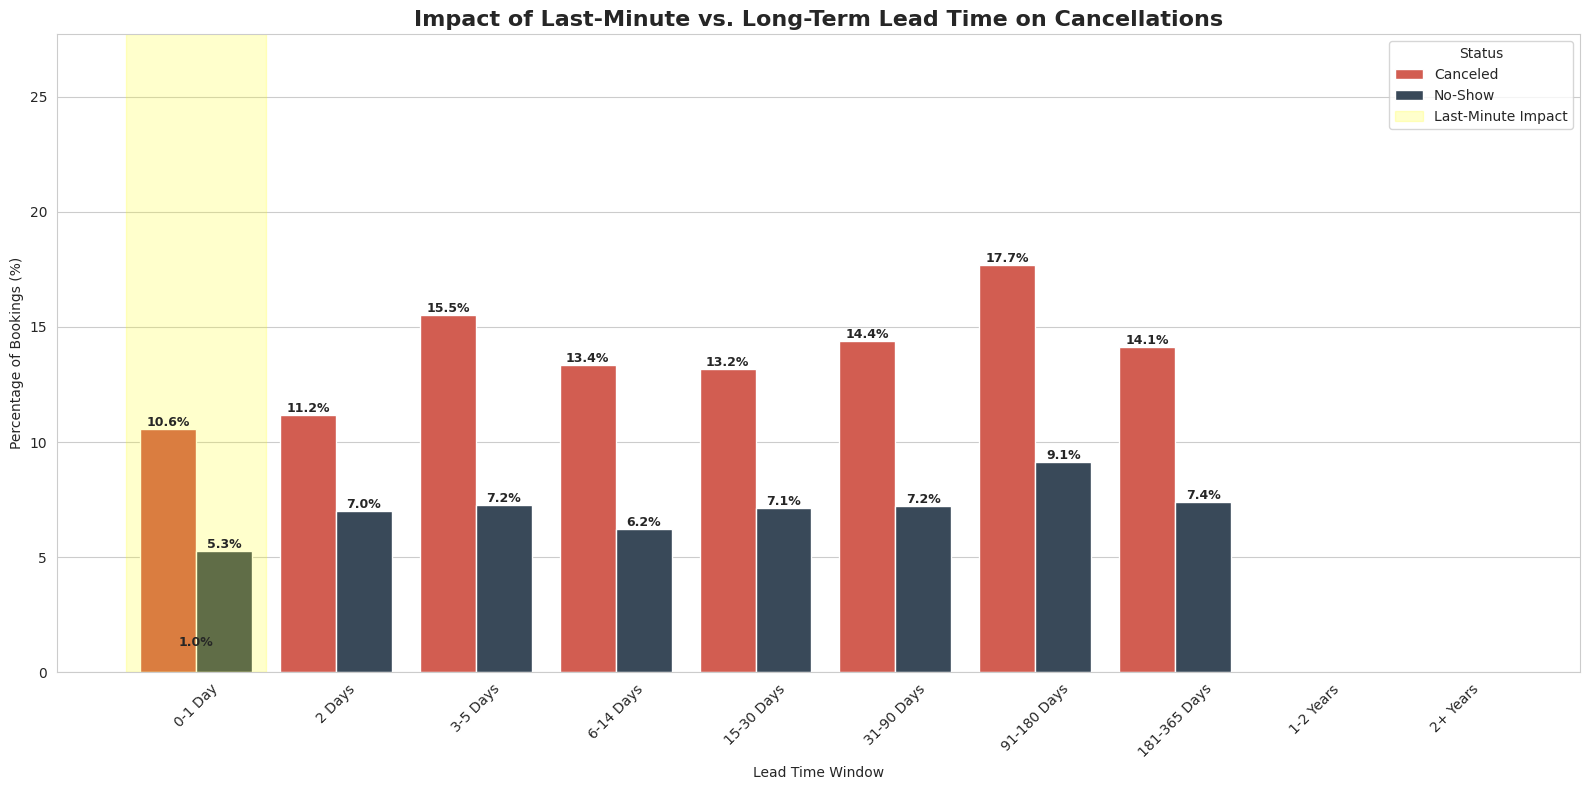

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 1. New Binning Strategy: Granite-level detail for start, wide for end
# We add 0, 1, 2, 5 to see the "Immediate" window clearly
bins = [0, 1, 2, 5, 14, 30, 90, 180, 365, 730, 1000]
labels = ['0-1 Day', '2 Days', '3-5 Days', '6-14 Days', '15-30 Days',
          '31-90 Days', '91-180 Days', '181-365 Days', '1-2 Years', '2+ Years']

df['Lead_Time_Range'] = pd.cut(df['Lead_Time'], bins=bins, labels=labels, include_lowest=True)

# 2. Calculate rates
# Using observed=False to ensure all bins show up even if empty
status_counts = df.groupby(['Lead_Time_Range', 'Reservation_Status'], observed=False).size().unstack(fill_value=0)
status_percentages = status_counts.div(status_counts.sum(axis=1), axis=0).fillna(0) * 100

# 3. Prepare data
plot_data = status_percentages.reset_index()
# Check if 'No-Show' exists in your data, if not, this avoids errors
cols_to_melt = [c for c in ['Canceled', 'No-Show'] if c in plot_data.columns]
plot_data_melted = plot_data.melt(id_vars='Lead_Time_Range', value_vars=cols_to_melt,
                                 var_name='Status', value_name='Rate')

# 4. Visualization
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

ax = sns.barplot(data=plot_data_melted, x='Lead_Time_Range', y='Rate', hue='Status', palette=['#e74c3c', '#34495e'])

# HIGHLIGHT: The "Last Minute" Zone (The first bar)
plt.axvspan(-0.5, 0.5, color='yellow', alpha=0.2, label='Last-Minute Impact')

# Add data labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Impact of Last-Minute vs. Long-Term Lead Time on Cancellations', fontsize=16, fontweight='bold')
plt.ylabel('Percentage of Bookings (%)')
plt.xlabel('Lead Time Window')
plt.xticks(rotation=45)
plt.legend(title='Status', loc='upper right')
plt.ylim(0, max(plot_data_melted['Rate']) + 10)

plt.tight_layout()
plt.show()

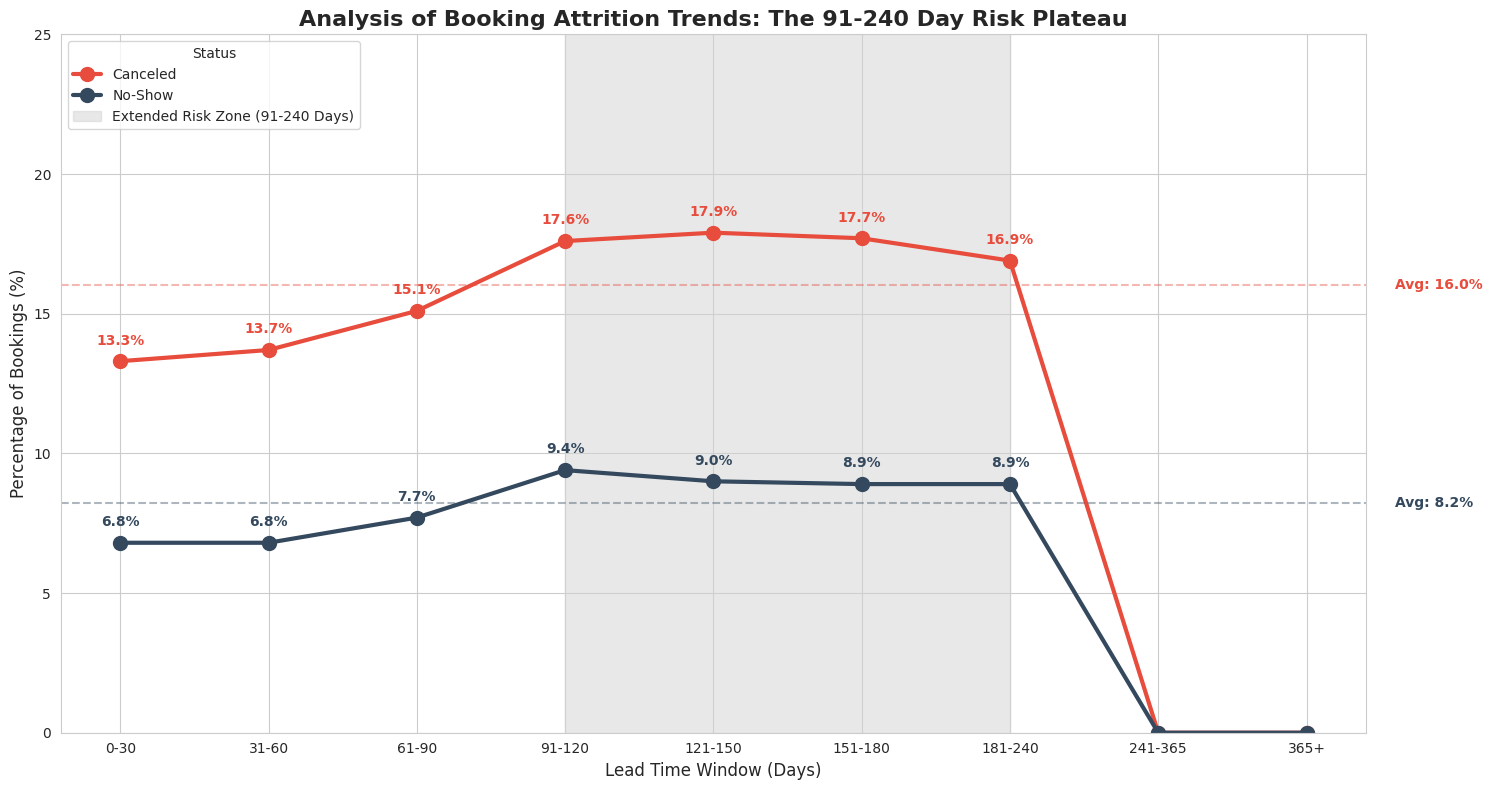

In [6]:

# 1. Data Setup
data = {
    'Lead_Time_Range': ['0-30', '31-60', '61-90', '91-120', '121-150', '151-180', '181-240', '241-365', '365+'],
    'Canceled': [13.3, 13.7, 15.1, 17.6, 17.9, 17.7, 16.9, 0.0, 0.0],
    'No-Show': [6.8, 6.8, 7.7, 9.4, 9.0, 8.9, 8.9, 0.0, 0.0]
}
plot_data = pd.DataFrame(data)

# Calculate averages for active bins (0-240 days)
active_data = plot_data[plot_data['Canceled'] > 0]
avg_canceled = active_data['Canceled'].mean()
avg_noshow = active_data['No-Show'].mean()

# 2. Plotting
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

colors = {'Canceled': '#e74c3c', 'No-Show': '#34495e'}

for status in ['Canceled', 'No-Show']:
    plt.plot(plot_data['Lead_Time_Range'], plot_data[status],
             marker='o', markersize=10, linewidth=3,
             color=colors[status], label=status)

    # Annotate markers with percentages
    for i, val in enumerate(plot_data[status]):
        if val > 0:
            plt.annotate(f'{val:.1f}%', (plot_data['Lead_Time_Range'][i], val),
                        xytext=(0, 12), textcoords="offset points",
                        ha='center', fontsize=10, fontweight='bold', color=colors[status])

# 3. Add Horizontal Average Dotted Lines
plt.axhline(avg_canceled, color=colors['Canceled'], linestyle='--', alpha=0.4)
plt.axhline(avg_noshow, color=colors['No-Show'], linestyle='--', alpha=0.4)

# 4. Placement of average values at the END of the lines
# We use the length of the x-axis to place the text at the far right
plt.text(len(plot_data)-0.4, avg_canceled, f'Avg: {avg_canceled:.1f}%',
         va='center', fontweight='bold', color=colors['Canceled'], backgroundcolor='white')
plt.text(len(plot_data)-0.4, avg_noshow, f'Avg: {avg_noshow:.1f}%',
         va='center', fontweight='bold', color=colors['No-Show'], backgroundcolor='white')

# 5. Highlight: Extended Risk Zone (91-240 Days) in Light Gray
plt.axvspan(3, 6, color='lightgray', alpha=0.5, label='Extended Risk Zone (91-240 Days)')

# Formatting
plt.title('Analysis of Booking Attrition Trends: The 91-240 Day Risk Plateau', fontsize=16, fontweight='bold')
plt.ylabel('Percentage of Bookings (%)', fontsize=12)
plt.xlabel('Lead Time Window (Days)', fontsize=12)
plt.legend(title='Status', loc='upper left')
plt.ylim(0, 25)

plt.tight_layout()
plt.show()

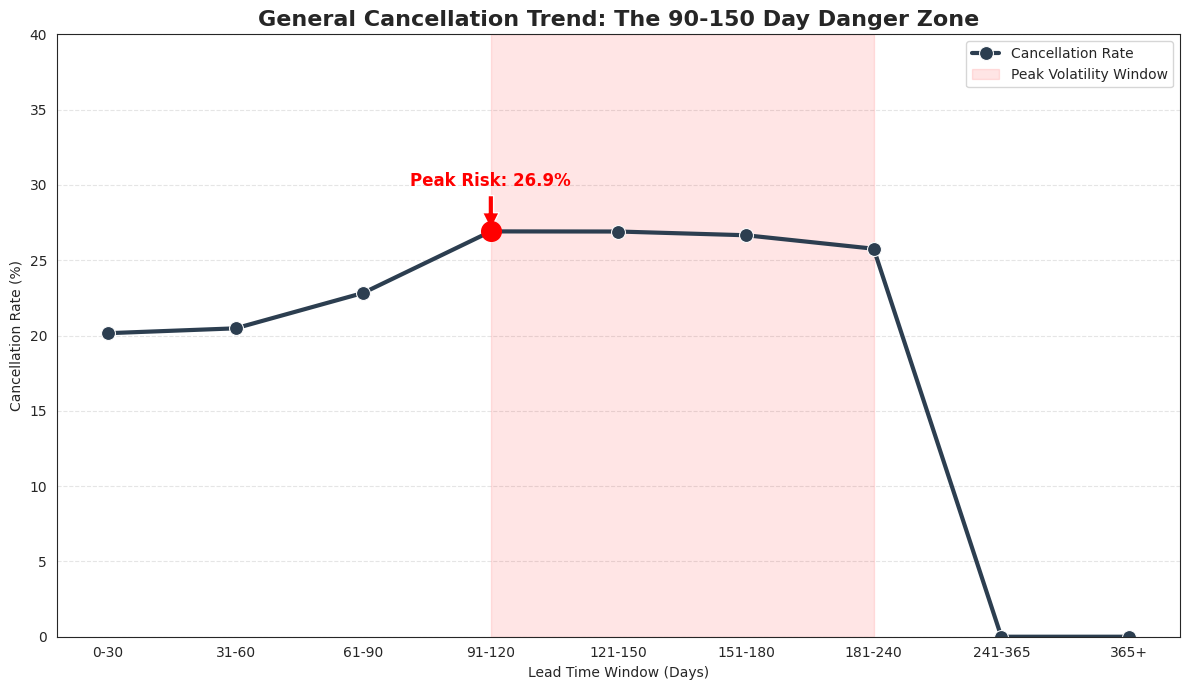

In [7]:

# 2. Create Lead Time Bins
bins = [0, 30, 60, 90, 120, 150, 180, 240, 365, 1000]
labels = ['0-30', '31-60', '61-90', '91-120', '121-150', '151-180', '181-240', '241-365', '365+']
df['Lead_Time_Range'] = pd.cut(df['Lead_Time'], bins=bins, labels=labels)

# Create Is_Cancelled column (if it doesn't already exist from a previous cell)
df['Is_Cancelled'] = df['Reservation_Status'].apply(lambda x: 1 if x in ['Canceled', 'No-Show'] else 0)

# 3. Calculate Global Cancellation Rate per Bin
general_trend = df.groupby('Lead_Time_Range', observed=True)['Is_Cancelled'].mean().reset_index()
general_trend['Cancellation_Rate'] = general_trend['Is_Cancelled'] * 100

# 4. Identify the Volatile Bin
max_rate = general_trend['Cancellation_Rate'].max()
peak_bin = general_trend.loc[general_trend['Cancellation_Rate'].idxmax(), 'Lead_Time_Range']

# 5. Plotting
plt.figure(figsize=(12, 7))
sns.set_style("white")

# Main line
sns.lineplot(data=general_trend, x='Lead_Time_Range', y='Cancellation_Rate',
             marker='o', markersize=10, linewidth=3, color='#2c3e50', label='Cancellation Rate')

# Highlight the peak bin (Danger Zone)
plt.axvspan('91-120', '181-240', color='red', alpha=0.1, label='Peak Volatility Window')
plt.scatter(peak_bin, max_rate, color='red', s=200, zorder=5)

# Annotation
plt.annotate(f'Peak Risk: {max_rate:.1f}%',
             xy=(peak_bin, max_rate), xytext=(peak_bin, max_rate + 3),
             ha='center', fontsize=12, fontweight='bold', color='red',
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.title('General Cancellation Trend: The 90-150 Day Danger Zone', fontsize=16, fontweight='bold')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Lead Time Window (Days)')
plt.ylim(0, 40)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

The "Above Average" Window: You can now see that the risk for both categories crosses the average line exactly at the 91-day mark and stays above it until the end of the 181-240 day bin. This confirms that the highlighted gray area is mathematically your "High-Risk" zone.

Cancellation Average: Hovers around 16.0%. Any booking in the gray zone is significantly higher than this baseline.

No-Show Average: Hovers around 8.2%. The peaks in the gray zone (up to 9.4%) represent a notable increase in "silent" revenue loss.

/tmp/ipykernel_3173/1230264969.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['Lead_Time_Bin', 'Reservation_Status']).size().unstack(fill_value=0)


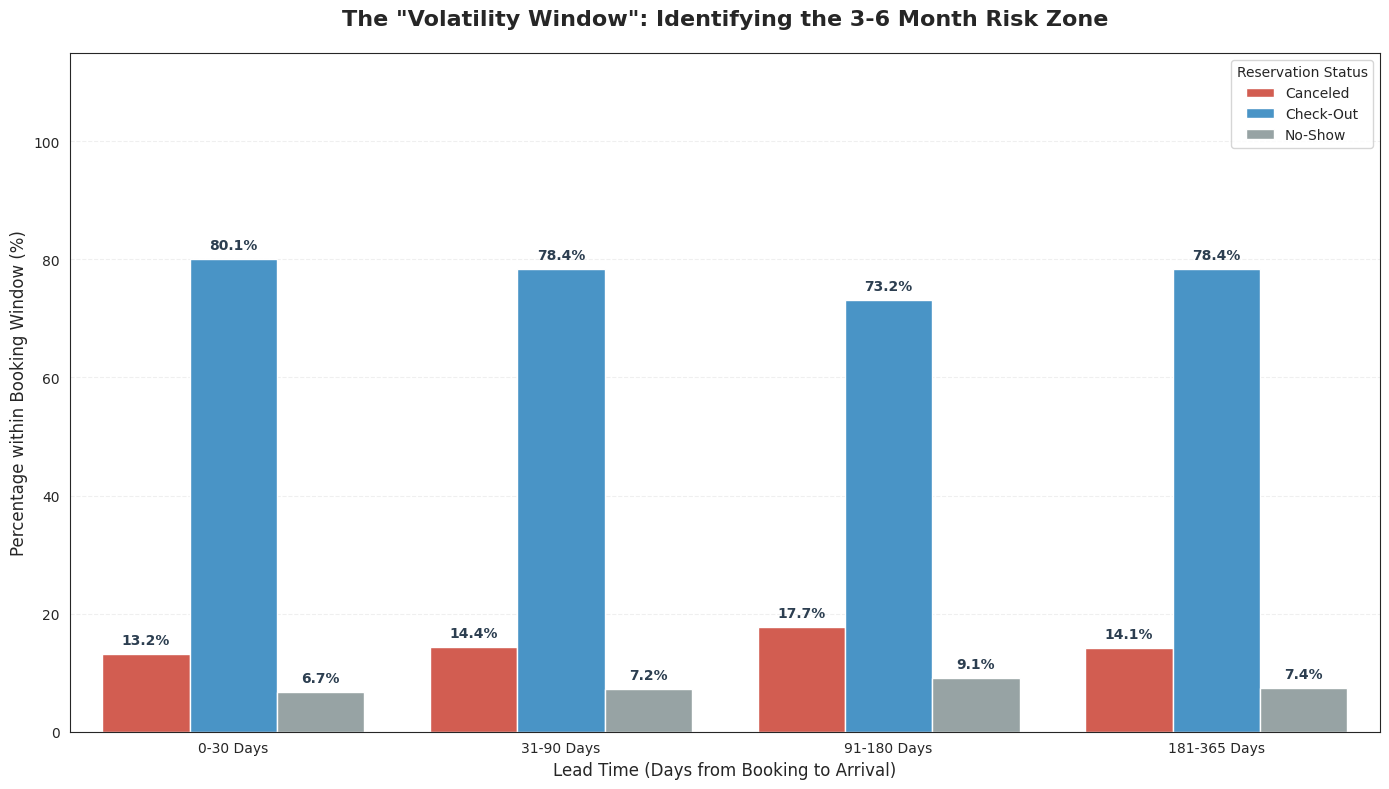

In [8]:

# 2. Create Lead Time Bins
# We define these specific ranges to isolate the "Danger Zone" (91-180 days)
df['Lead_Time_Bin'] = pd.cut(df['Lead_Time'],
                            bins=[-1, 30, 90, 180, 365],
                            labels=['0-30 Days', '31-90 Days', '91-180 Days', '181-365 Days'])

# 3. Calculate Percentages (Neutralizing Class Imbalance)
# We group by the bin and status, then divide by the total in each bin
counts = df.groupby(['Lead_Time_Bin', 'Reservation_Status']).size().unstack(fill_value=0)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100
plot_df = percentages.reset_index().melt(id_vars='Lead_Time_Bin', var_name='Status', value_name='Percentage')

# 4. Plotting with non-green colors
# Blue for success, Red for high-risk, Grey for neutral no-shows
custom_colors = {'Check-Out': '#3498db', 'Canceled': '#e74c3c', 'No-Show': '#95a5a6'}

plt.figure(figsize=(14, 8))
ax = sns.barplot(data=plot_df, x='Lead_Time_Bin', y='Percentage', hue='Status', palette=custom_colors)

# 5. Add Percentage Labels on top of each bar
for p in ax.patches:
    val = p.get_height()
    if val > 0:
        ax.annotate(f'{val:.1f}%',
                    (p.get_x() + p.get_width() / 2., val),
                    ha='center', va='center',
                    xytext=(0, 10),
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='#2c3e50')

# 6. Styling and Labels
plt.title('The "Volatility Window": Identifying the 3-6 Month Risk Zone', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Percentage within Booking Window (%)', fontsize=12)
plt.xlabel('Lead Time (Days from Booking to Arrival)', fontsize=12)
plt.ylim(0, 115)  # Space for labels
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='Reservation Status', loc='upper right')

plt.tight_layout()
plt.show()

In [9]:

# 2. Filter for lead time > 365 days
long_lead_rows = df[df['Lead_Time'] > 365]

# 3. View the total count and the first few records
print(f"Total Rows with Lead Time > 365: {len(long_lead_rows)}")
print(long_lead_rows.head(10))

# 4. Save to a separate CSV for detailed inspection
long_lead_rows.to_csv('long_lead_rows_exact.csv', index=False)

Total Rows with Lead Time > 365: 217
      Reservation-id Gender  Age         Ethnicity Educational_Level  \
75          54294175      M   40  African American           College   
209         91794758      M   25            Latino           College   
838         27321174      M   53    Asian American           College   
1436        94501191      M   66         caucasian       High-School   
1582        42111482      F   42  African American           College   
2239        28381659      F   61            Latino       High-School   
3921        81524080      M   65    Asian American              Grad   
5418        69520632      M   51         caucasian           College   
5419        23459267      F   37         caucasian        Mid-School   
5421         2817139      M   18  African American        Mid-School   

           Income Country_region      Hotel_Type Expected_checkin  \
75    50K -- 100K          North  Airport Hotels       2015-05-19   
209     25K --50K          North

In [10]:
print(long_lead_rows[['Visted_Previously']])

     Visted_Previously
75                 Yes
209                 No
838                 No
1436                No
1582               Yes
...                ...
8849                No
8850                No
8851               Yes
8852               Yes
8853                No

[217 rows x 1 columns]


##Revenue loss drivers by Hotel category

/tmp/ipykernel_3173/2588312166.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


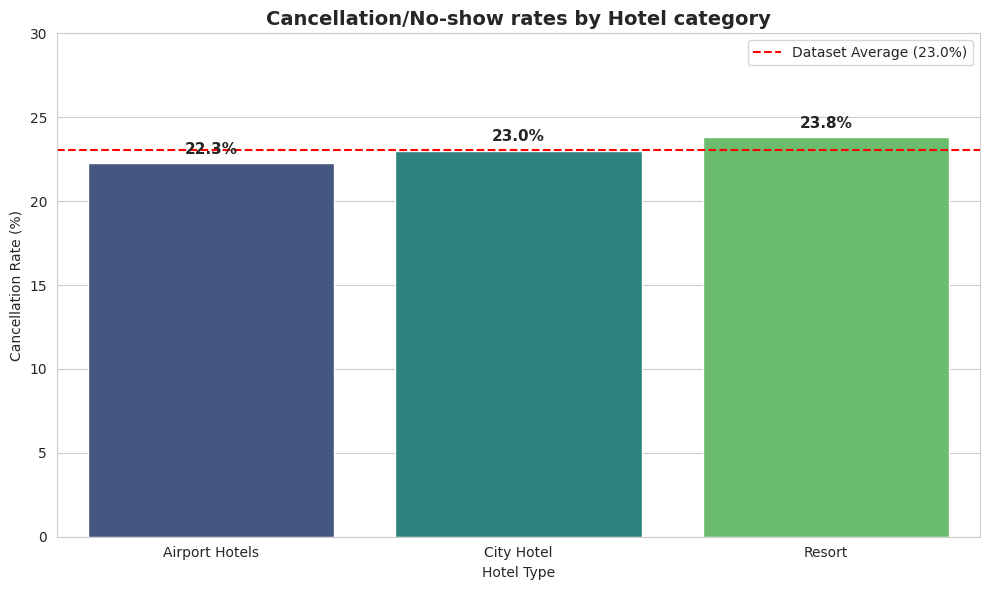

In [11]:

# 2. Binary target for Cancellation + No-Show
df['Is_Cancelled'] = df['Reservation_Status'].apply(lambda x: 1 if x in ['Canceled', 'No-Show'] else 0)

# 3. Calculate Overall Mean for the reference line
overall_mean = df['Is_Cancelled'].mean() * 100

# 4. Calculate Risk by Hotel Type
hotel_stats = df.groupby('Hotel_Type')['Is_Cancelled'].mean().reset_index()
hotel_stats['Cancellation_Rate'] = hotel_stats['Is_Cancelled'] * 100

# 5. The Visualization
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create the bar plot
ax = sns.barplot(
    data=hotel_stats,
    x='Hotel_Type',
    y='Cancellation_Rate',
    palette='viridis'
)

# 6. Add the "Baseline" Reference Line
plt.axhline(overall_mean, color='red', linestyle='--', label=f'Dataset Average ({overall_mean:.1f}%)')

# 7. Annotate individual bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# Formatting
plt.title('Cancellation/No-show rates by Hotel category', fontsize=14, fontweight='bold')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Hotel Type')
plt.ylim(0, 30)
plt.legend()

plt.tight_layout()
plt.show()

If 100 people book a Resort, 23.8 of them will cancel.

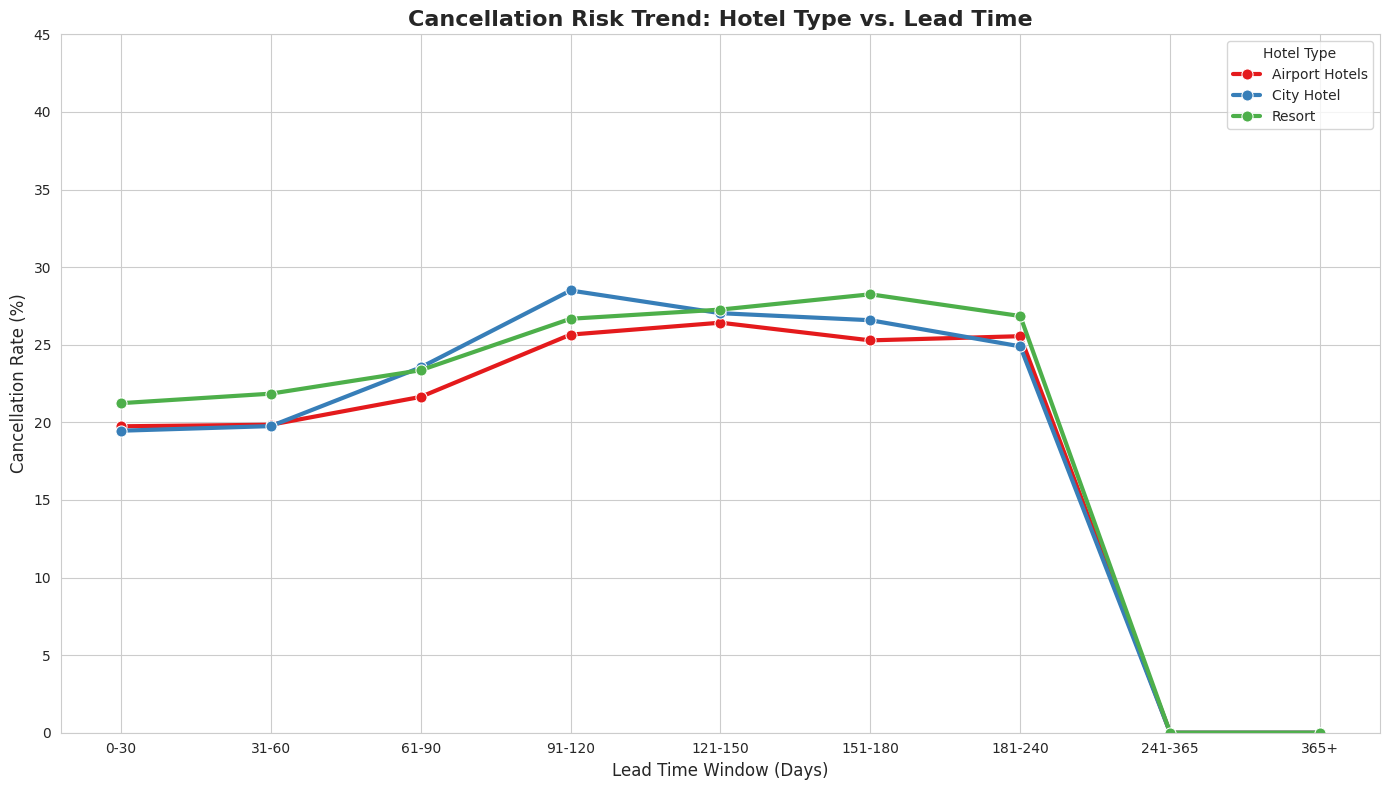

In [12]:

df['Is_Cancelled'] = df['Reservation_Status'].apply(lambda x: 1 if x in ['Canceled', 'No-Show'] else 0)

# 2. Granular Lead Time Bins (to capture the "curve")
bins = [0, 30, 60, 90, 120, 150, 180, 240, 365, 1000]
labels = ['0-30', '31-60', '61-90', '91-120', '121-150', '151-180', '181-240', '241-365', '365+']
df['Lead_Time_Range'] = pd.cut(df['Lead_Time'], bins=bins, labels=labels)

# 3. Calculate Risk Trend
trend_data = df.groupby(['Lead_Time_Range', 'Hotel_Type'], observed=True)['Is_Cancelled'].mean().reset_index()
trend_data['Cancellation_Rate'] = trend_data['Is_Cancelled'] * 100

# 4. Generate the Plot
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.lineplot(data=trend_data, x='Lead_Time_Range', y='Cancellation_Rate', hue='Hotel_Type',
             marker='o', markersize=8, linewidth=3, palette='Set1')

plt.title('Cancellation Risk Trend: Hotel Type vs. Lead Time', fontsize=16, fontweight='bold')
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.xlabel('Lead Time Window (Days)', fontsize=12)
plt.ylim(0, 45)
plt.legend(title='Hotel Type')

plt.tight_layout()
plt.show()

Airport hotels remain the most "rational" segment. Their risk curve is flatter and peaks lower than the others, confirming they are largely used for functional travel which is rarely cancelled once planned.

#Meal type vs Cancellation

/tmp/ipykernel_3173/3348156929.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=meal_plot_df, x='Meal_Type', y='is_cancelled', palette='viridis')


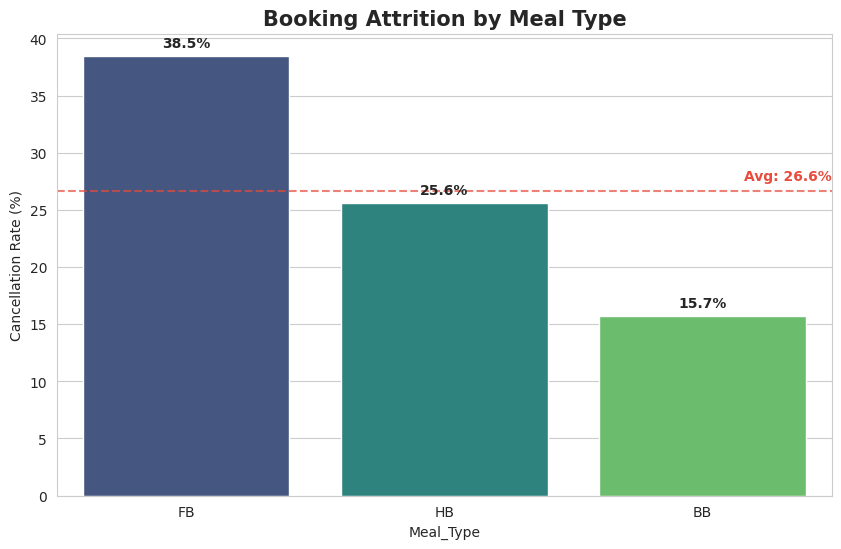

In [13]:
# 1. Group by Meal Type and take the mean of your binary column
# multiplying by 100 turns the decimal (0.38) into a percentage (38.0%)
meal_plot_df = df.groupby('Meal_Type')['Is_Cancelled'].mean().reset_index()
meal_plot_df['is_cancelled'] = meal_plot_df['Is_Cancelled'] * 100

# 2. Sort for the graph
meal_plot_df = meal_plot_df.sort_values('is_cancelled', ascending=False)

# 3. Calculate benchmark
global_avg_meal = meal_plot_df['is_cancelled'].mean()

# 4. Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax1 = sns.barplot(data=meal_plot_df, x='Meal_Type', y='is_cancelled', palette='viridis')

# Annotate bars with the percentages
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),
                textcoords='offset points', fontweight='bold')

# Benchmark Average Line
plt.axhline(global_avg_meal, color='#e74c3c', linestyle='--', alpha=0.7)
plt.text(len(meal_plot_df)-0.5, global_avg_meal + 1, f'Avg: {global_avg_meal:.1f}%',
         color='#e74c3c', fontweight='bold', ha='right')

plt.title('Booking Attrition by Meal Type', fontsize=15, fontweight='bold')
plt.ylabel('Cancellation Rate (%)')
plt.show()

##Seasonal trends

/tmp/ipykernel_3173/572298128.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(day_labels)


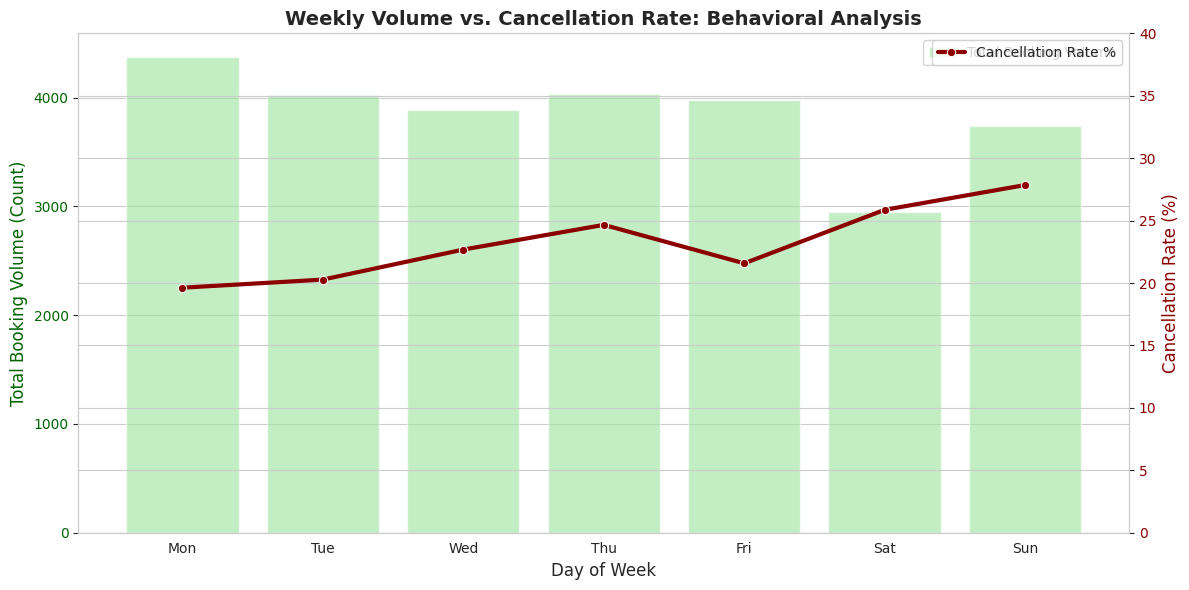

Weekly Summary Stats:
   Checkin_Day_of_Week  Total_Bookings  Cancellation_Rate_Pct
0                    0            4372              19.624886
1                    1            4025              20.273292
2                    2            3889              22.679352
3                    3            4031              24.658894
4                    4            3981              21.577493
5                    5            2950              25.864407
6                    6            3738              27.849117


In [14]:


# 2. Define the binary cancellation target
# 1 if the reservation was cancelled or a no-show, 0 if they checked out
df['Is_Cancelled'] = df['Reservation_Status'].apply(
    lambda x: 1 if x in ['Canceled', 'No-Show'] else 0
)

# 3. Aggregate data by Day of the Week
# We calculate the count (Volume) and the mean (Cancellation Rate)
weekly_stats = df.groupby('Checkin_Day_of_Week').agg(
    Total_Bookings=('Is_Cancelled', 'count'),
    Cancellation_Rate=('Is_Cancelled', 'mean')
).reset_index()

# Convert rate to percentage for better readability
weekly_stats['Cancellation_Rate_Pct'] = weekly_stats['Cancellation_Rate'] * 100

# Map numeric days to names (Assuming 0 = Monday, 6 = Sunday)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# 4. Create the Visualization
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot 1: Total Volume (Bar Chart on the Left Axis)
sns.barplot(
    data=weekly_stats,
    x='Checkin_Day_of_Week',
    y='Total_Bookings',
    color='lightgreen',
    alpha=0.6,
    ax=ax1,
    label='Total Booking Volume'
)
ax1.set_xlabel('Day of Week', fontsize=12)
ax1.set_ylabel('Total Booking Volume (Count)', color='darkgreen', fontsize=12)
ax1.tick_params(axis='y', labelcolor='darkgreen')
ax1.set_xticklabels(day_labels)

# Create a second y-axis for the Cancellation Rate
ax2 = ax1.twinx()

# Plot 2: Cancellation Rate (Line Chart on the Right Axis)
sns.lineplot(
    data=weekly_stats,
    x='Checkin_Day_of_Week',
    y='Cancellation_Rate_Pct',
    color='darkred',
    marker='o',
    linewidth=3,
    ax=ax2,
    label='Cancellation Rate %'
)
ax2.set_ylabel('Cancellation Rate (%)', color='darkred', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkred')

# Set y-axis limits to make the trend clear (0% to 40%)
ax2.set_ylim(0, 40)

# Final formatting
plt.title('Weekly Volume vs. Cancellation Rate: Behavioral Analysis', fontsize=14, fontweight='bold')
fig.tight_layout()

# Save the plot
plt.savefig('weekly_volume_vs_rate.png')
plt.show()

# 5. Print the raw stats for the report
print("Weekly Summary Stats:")
print(weekly_stats[['Checkin_Day_of_Week', 'Total_Bookings', 'Cancellation_Rate_Pct']])

Our analysis confirms that timing is a critical factor in booking attrition. Using Chi-Squared tests, we found that Monthly, Daily, and Weekend variations are statistically significant (p<0.001) rather than random. Specifically, August represents a high-risk seasonal peak, and weekend check-ins carry a significantly higher probability of cancellation compared to midweek arrivals. This suggests the hotel should apply stricter overbooking or cancellation policies during peak summer months and weekend periods.

Our weekly volume analysis completely deconstructs the idea that 'more guests = more cancellations.' In fact, the relationship is inverted on weekends: while Saturday check-ins represent our lowest volume of the week, they carry a 6% higher risk than our high-volume Mondays. This suggests that the hotel should focus its most stringent 'Confirmation Calls' and deposit policies on Saturday/Sunday arrivals, regardless of how many rooms are actually booked

In [17]:
df.dtypes

,0
Reservation-id,int64
Gender,object
Age,int64
Ethnicity,object
Educational_Level,object
Income,object
Country_region,object
Hotel_Type,object
Expected_checkin,object
Expected_checkout,object


<Figure size 1000x600 with 0 Axes>

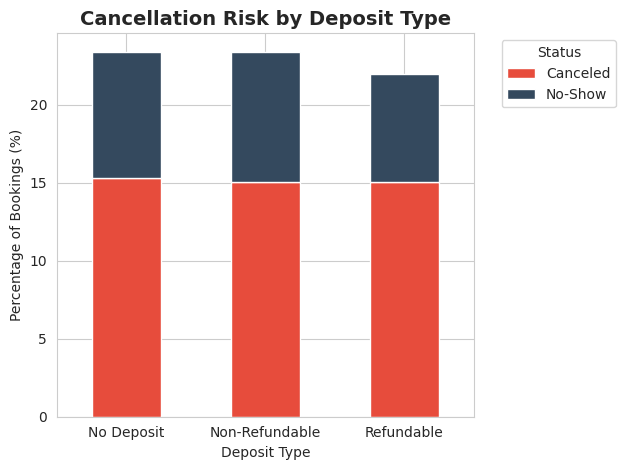

In [19]:
# Grouping by Deposit Type and Status to see the distribution
deposit_impact = df.groupby(['Deposit_type', 'Reservation_Status'], observed=True).size().unstack(fill_value=0)

# Calculate percentages to see the relative risk
deposit_risk = deposit_impact.div(deposit_impact.sum(axis=1), axis=0) * 100

# Plotting
plt.figure(figsize=(10, 6))
deposit_risk[['Canceled', 'No-Show']].plot(kind='bar', stacked=True, color=['#e74c3c', '#34495e'])

plt.title('Cancellation Risk by Deposit Type', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Bookings (%)')
plt.xlabel('Deposit Type')
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3173/3327041201.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dep_perc.index, y=dep_perc['Canceled'], ax=ax1, palette='Reds_r')
/tmp/ipykernel_3173/3327041201.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dep_perc.index, y=dep_perc['No-Show'], ax=ax2, palette='Blues_r')


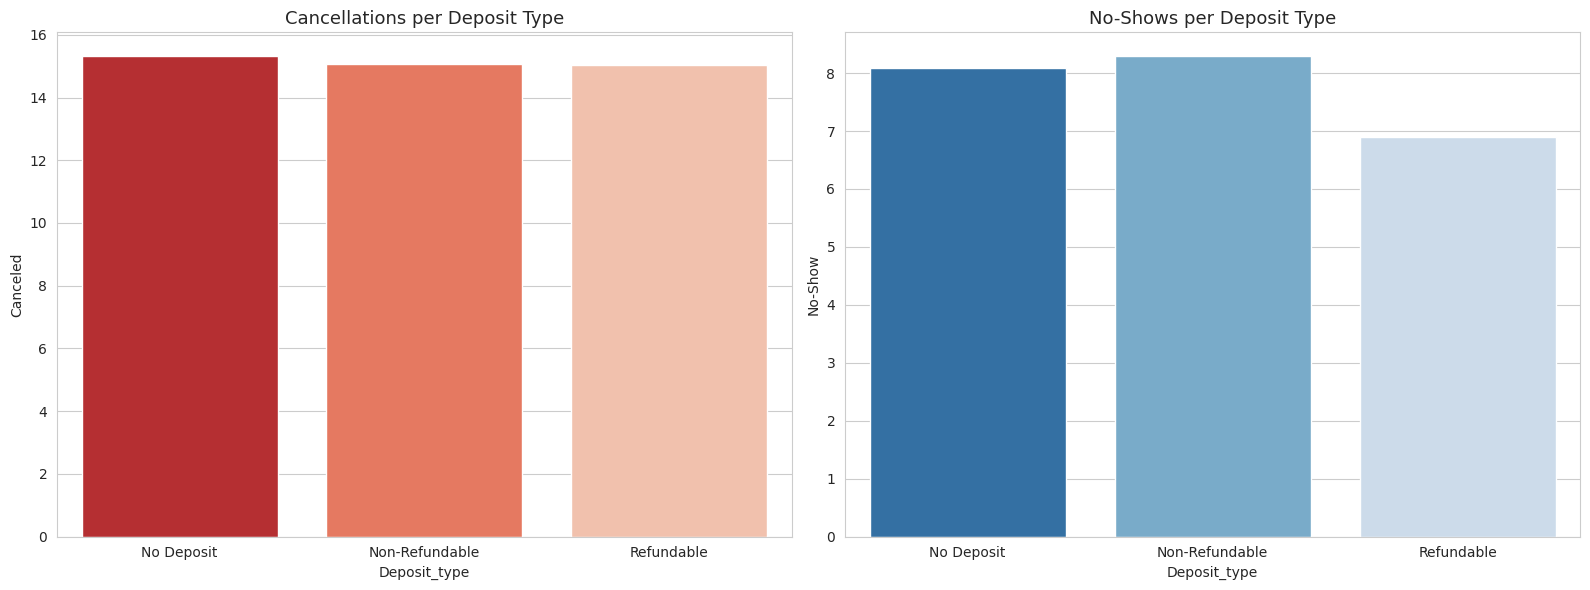

In [21]:
# 1. Prepare data
dep_counts = df.groupby(['Deposit_type', 'Reservation_Status'], observed=True).size().unstack(fill_value=0)
dep_perc = dep_counts.div(dep_counts.sum(axis=1), axis=0) * 100

# 2. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Cancellations
sns.barplot(x=dep_perc.index, y=dep_perc['Canceled'], ax=ax1, palette='Reds_r')
ax1.set_title('Cancellations per Deposit Type', fontsize=13)

# No-Shows
sns.barplot(x=dep_perc.index, y=dep_perc['No-Show'], ax=ax2, palette='Blues_r')
ax2.set_title('No-Shows per Deposit Type', fontsize=13)

plt.tight_layout()
plt.show()